# unsupervised dimensionality reduction: PCA 

textbook rujukan: [Raschka, S. and Mirjalili, V., 2019. Python Machine Learning. 3rd ed. Birmingham: Packt Publishing.](https://drive.google.com/file/d/18lHZBFrdOK8a1t1Vyx1v9GjiF81EWOo4/view?usp=sharing)

steps:
1. Standardize the d-dimensional dataset.
2. Construct the covariance matrix.
3. Decompose the covariance matrix into its eigenvectors and eigenvalues.
4. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
5. Select k eigenvectors, which correspond to the k largest eigenvalues, where k is the dimensionality of the new feature subspace (kk ≤ dd).
6. Construct a projection matrix, W, from the "top" k eigenvectors.
7. Transform the d-dimensional input dataset, X, using the projection matrix, W, to obtain the new k-dimensional feature subspace.

dataset: https://archive.ics.uci.edu/dataset/42/glass+identification

## import, setup, konfigurasi, dataset

In [6]:
import sys
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# konfigurasi logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)])

# setup direktori
current_dir = Path.cwd()
logging.info(f"working directory: {current_dir}")

# dataset
col_names = ['id', 'ri', 'na', 'mg', 'al', 'si', 'k', 'ca', 'ba', 'fe', 'type']
df_glass = pd.read_csv("glass.data", names=col_names)
df_glass = df_glass.drop(columns=['id'])

# memisahkan fitur matrix dan target
X = df_glass.drop(columns=['type']).values
y = df_glass['type'].values
logging.info(f"dimensi feature matrix (X): {X.shape}")
logging.info(f"dimensi target array (y): {y.shape}")

display(df_glass.head())

2026-03-13 03:19:23,883 - INFO - working directory: /home/cation-pi/Documents/kelompokD_sk5004/pca
2026-03-13 03:19:23,887 - INFO - dimensi feature matrix (X): (214, 9)
2026-03-13 03:19:23,888 - INFO - dimensi target array (y): (214,)


,ri,na,mg,al,si,k,ca,ba,fe,type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## step 1: standardisasi dataset (Z-score)

In [2]:
logging.info("memulai step 1: standardisasi dataset...")

mean_vec = np.mean(X, axis=0)
std_vec = np.std(X, axis=0)

X_std = (X - mean_vec) / std_vec

logging.info(f"rata-rata X_std: {np.mean(X_std):.20f}")
logging.info(f"standar deviasi X_std: {np.std(X_std):.20f}")

df_std_preview = pd.DataFrame(X_std, columns=col_names[1:-1])
display(df_std_preview.head())

2026-03-13 02:19:42,398 - INFO - memulai step 1: standardisasi dataset...
2026-03-13 02:19:42,400 - INFO - rata-rata X_std: -0.00000000000000293293
2026-03-13 02:19:42,401 - INFO - standar deviasi X_std: 1.00000000000000000000


,ri,na,mg,al,si,k,ca,ba,fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451


## step 2 dan 3:
- membuat covariance matrix
- mencari eigenvector dan eigenvalue

In [3]:
# step 2
cov_mat = np.cov(X_std.T)
logging.info(f"dimensi covariance matrix: {cov_mat.shape}")

# step 3: Σv = λv
# Σ = cov_mat, v = eigenvector, λ = eigenvalue.
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
logging.info(f"jumlah eigenvalues: {len(eigen_vals)}")
logging.info(f"dimensi matriks eigenvectors: {eigen_vecs.shape}")
print('\nEigenvalues:')
print(eigen_vals)

2026-03-13 02:48:26,808 - INFO - dimensi covariance matrix: (9, 9)
2026-03-13 02:48:26,819 - INFO - jumlah eigenvalues: 9
2026-03-13 02:48:26,820 - INFO - dimensi matriks eigenvectors: (9, 9)

Eigenvalues:
[2.52295323e+00 2.05969694e+00 1.41143951e+00 1.16329842e+00
 9.18293337e-01 5.30112353e-01 3.70690643e-01 6.41527269e-02
 1.61637096e-03]


## step 4, 5, dan 6:
- sorting eigenvalues (besar ke kecil)
- memilih k eigenvectors (variance plot)
- membuat projection matrix 

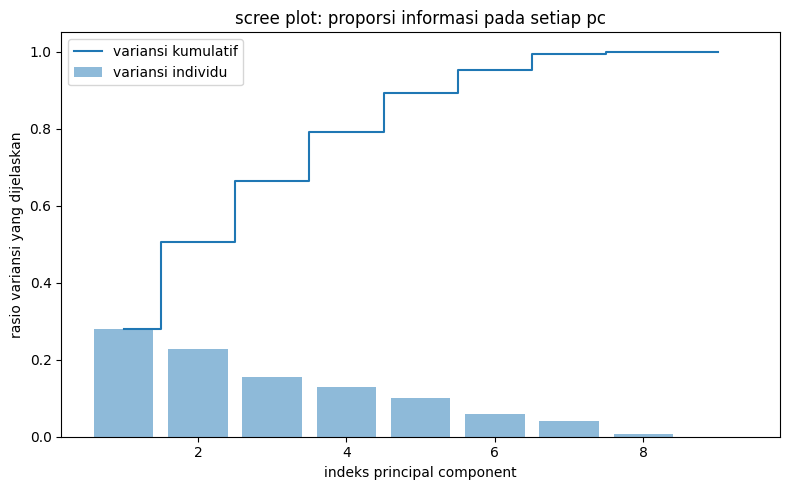

2026-03-13 03:16:49,949 - INFO - dimensi matriks proyeksi w: (9, 2)
matriks w:
 [[-0.54517662  0.28568318]
 [ 0.2581256   0.27035007]
 [-0.11088095 -0.59355826]
 [ 0.42870863  0.29521154]
 [ 0.22883635 -0.15509891]
 [ 0.21934405 -0.15397013]
 [-0.49230609  0.3453798 ]
 [ 0.25037512  0.48470218]
 [-0.18584154 -0.06203879]]


In [5]:
# step 4
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 10), var_exp, alpha=0.5, align='center', label='variansi individu')
plt.step(range(1, 10), cum_var_exp, where='mid', label='variansi kumulatif')
plt.ylabel('rasio variansi yang dijelaskan')
plt.xlabel('indeks principal component')
plt.legend(loc='best')
plt.title('scree plot: proporsi informasi pada setiap pc')
plt.tight_layout()
plt.show()

# step 5 dan 6
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

w = np.hstack((eigen_pairs[0][1][:, np.newaxis], eigen_pairs[1][1][:, np.newaxis]))
logging.info(f"dimensi matriks proyeksi w: {w.shape}")
print('matriks w:\n', w)

## step 7: transformasi dan visualisasi

2026-03-13 03:24:27,499 - INFO - dimensi dataset sebelum pca: (214, 9)
2026-03-13 03:24:27,499 - INFO - dimensi dataset setelah pca: (214, 2)


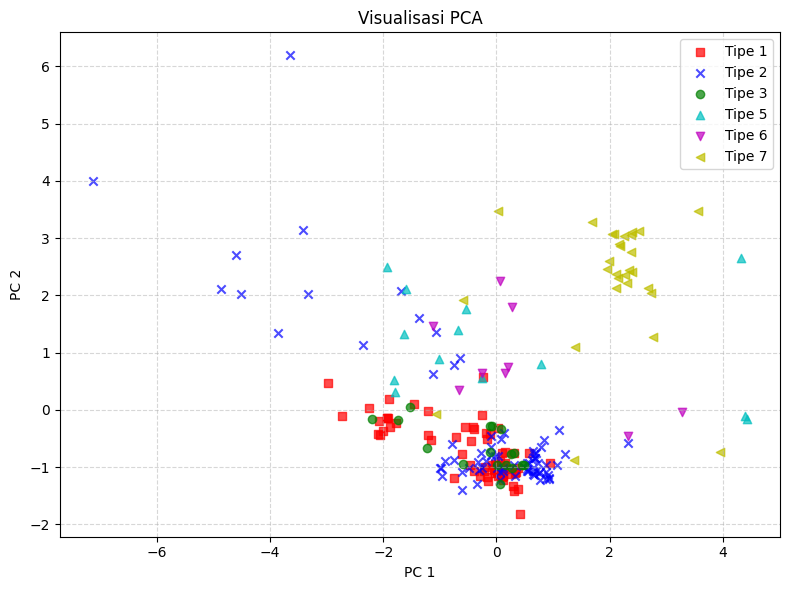

In [7]:
X_pca = X_std.dot(w)

logging.info(f"dimensi dataset sebelum pca: {X_std.shape}")
logging.info(f"dimensi dataset setelah pca: {X_pca.shape}")

# visualisasi
classes = np.unique(y)
colors = ['r', 'b', 'g', 'c', 'm', 'y']
markers = ['s', 'x', 'o', '^', 'v', '<']

plt.figure(figsize=(8, 6))

for l, c, m in zip(classes, colors, markers):
    plt.scatter(X_pca[y == l, 0], X_pca[y == l, 1], c=c, label=f'Tipe {l}', marker=m, alpha=0.7)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='best')
plt.title('Visualisasi PCA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()